In [ ]:
!pip install cartopy

In [ ]:
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm

In [ ]:
era5_file = 'ERA5_Land_2021346N05145.nc'
phl_boundary = 'PHL_adm0.shp'
phl_buffer = 'PHL_1degree_buffer.shp'
ibtracs_points = 'IBTrACS.WP.list.v04r01.points.shp'
ibtracs_lines = 'IBTrACS.WP.list.v04r01.lines.shp'

In [ ]:
phl_gdf = gpd.read_file(phl_boundary)
ibtracs_points_gdf = gpd.read_file(ibtracs_points)
ibtracs_lines_gdf = gpd.read_file(ibtracs_lines)

In [ ]:
rai_points = ibtracs_points_gdf[
    (ibtracs_points_gdf['SID'] == '2021346N05145')
]

rai_lines = ibtracs_lines_gdf[
   (ibtracs_lines_gdf['SID'] == '2021346N05145')
]

In [ ]:
rai_points

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,USA_SEA_SW,USA_SEA_NW,STORM_SPD,STORM_DR,year,month,day,hour,min,geometry
239876,2021346N05145,2021,104,WP,MM,RAI,2021-12-11 12:00:00,DS,5.3,145.0,...,NaN,NaN,2.0,295.0,2021,12,11,12,0,POINT (145 5.3)
239877,2021346N05145,2021,104,WP,MM,RAI,2021-12-11 15:00:00,DS,5.4,144.9,...,NaN,NaN,3.0,315.0,2021,12,11,15,0,POINT (144.89999 5.4)
239878,2021346N05145,2021,104,WP,MM,RAI,2021-12-11 18:00:00,MX,5.5,144.8,...,NaN,NaN,3.0,315.0,2021,12,11,18,0,POINT (144.8 5.5)
239879,2021346N05145,2021,104,WP,MM,RAI,2021-12-11 21:00:00,MX,5.6,144.7,...,NaN,NaN,2.0,275.0,2021,12,11,21,0,POINT (144.7 5.6)
239880,2021346N05145,2021,104,WP,MM,RAI,2021-12-12 00:00:00,MX,5.5,144.6,...,NaN,NaN,3.0,260.0,2021,12,12,0,0,POINT (144.60001 5.5)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239952,2021346N05145,2021,104,WP,MM,RAI,2021-12-21 00:00:00,MX,20.7,113.9,...,NaN,NaN,14.0,55.0,2021,12,21,0,0,POINT (113.9 20.7)
239953,2021346N05145,2021,104,WP,MM,RAI,2021-12-21 03:00:00,MX,21.1,114.5,...,NaN,NaN,15.0,60.0,2021,12,21,3,0,POINT (114.5 21.1)
239954,2021346N05145,2021,104,WP,MM,RAI,2021-12-21 06:00:00,MX,21.5,115.2,...,NaN,NaN,14.0,65.0,2021,12,21,6,0,POINT (115.2 21.5)
239955,2021346N05145,2021,104,WP,MM,RAI,2021-12-21 09:00:00,SS,21.7,115.9,...,NaN,NaN,12.0,80.0,2021,12,21,9,0,POINT (115.9 21.7)


In [ ]:
rai_lines

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,USA_SEA_SW,USA_SEA_NW,STORM_SPD,STORM_DR,year,month,day,hour,min,geometry
235770,2021346N05145,2021,104,WP,MM,RAI,2021-12-11 12:00:00,DS,5.3,145.0,...,NaN,NaN,2,295,2021,12,11,12,0,"LINESTRING (145 5.3, 144.90002 5.4)"
235771,2021346N05145,2021,104,WP,MM,RAI,2021-12-11 15:00:00,DS,5.4,144.9,...,NaN,NaN,3,315,2021,12,11,15,0,"LINESTRING (144.90002 5.4, 144.80005 5.5)"
235772,2021346N05145,2021,104,WP,MM,RAI,2021-12-11 18:00:00,MX,5.5,144.8,...,NaN,NaN,3,315,2021,12,11,18,0,"LINESTRING (144.80005 5.5, 144.69995 5.6)"
235773,2021346N05145,2021,104,WP,MM,RAI,2021-12-11 21:00:00,MX,5.6,144.7,...,NaN,NaN,2,275,2021,12,11,21,0,"LINESTRING (144.69995 5.6, 144.59998 5.5)"
235774,2021346N05145,2021,104,WP,MM,RAI,2021-12-12 00:00:00,MX,5.5,144.6,...,NaN,NaN,3,260,2021,12,12,0,0,"LINESTRING (144.59998 5.5, 144.40002 5.5)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235845,2021346N05145,2021,104,WP,MM,RAI,2021-12-20 21:00:00,MX,20.3,113.3,...,NaN,NaN,13,50,2021,12,20,21,0,"LINESTRING (113.30005 20.3, 113.90002 20.7)"
235846,2021346N05145,2021,104,WP,MM,RAI,2021-12-21 00:00:00,MX,20.7,113.9,...,NaN,NaN,14,55,2021,12,21,0,0,"LINESTRING (113.90002 20.7, 114.5 21.1)"
235847,2021346N05145,2021,104,WP,MM,RAI,2021-12-21 03:00:00,MX,21.1,114.5,...,NaN,NaN,15,60,2021,12,21,3,0,"LINESTRING (114.5 21.1, 115.19995 21.5)"
235848,2021346N05145,2021,104,WP,MM,RAI,2021-12-21 06:00:00,MX,21.5,115.2,...,NaN,NaN,14,65,2021,12,21,6,0,"LINESTRING (115.19995 21.5, 115.90002 21.7)"


In [ ]:
# Convert IBTrACS timestamps to datetime
rai_points['ISO_TIME'] = pd.to_datetime(rai_points['ISO_TIME'])

/usr/local/lib/python3.11/dist-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
buffer_gdf = gpd.read_file(phl_buffer)
buffer_geometry = buffer_gdf.geometry.iloc[0]  # Assume single polygon
# Create Point geometries for Rai's coordinates
rai_points['geometry'] = rai_points.apply(lambda row: Point(row['LON'], row['LAT']), axis=1)
rai_gdf = gpd.GeoDataFrame(rai_points, geometry='geometry', crs='EPSG:4326')
# Find points within the buffer
rai_in_buffer = rai_gdf[rai_gdf.within(buffer_geometry)]
# Get entry and exit times
entry_time = rai_in_buffer['ISO_TIME'].min()
exit_time = rai_in_buffer['ISO_TIME'].max()
print(f"Typhoon Rai in buffer from {entry_time} to {exit_time}")

Typhoon Rai in buffer from 2021-12-16 03:00:00 to 2021-12-17 15:00:00


/usr/local/lib/python3.11/dist-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
ds = xr.open_dataset(era5_file)
u = ds['u10']  # Eastward wind component (m/s)
v = ds['v10']  # Northward wind component (m/s)

In [ ]:
ds

<xarray.Dataset> Size: 89MB
Dimensions:     (valid_time: 192, latitude: 191, longitude: 151)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 2kB 2021-12-13 ... 2021-12-20T23:...
  * latitude    (latitude) float64 2kB 22.5 22.4 22.3 22.2 ... 3.8 3.7 3.6 3.5
  * longitude   (longitude) float64 1kB 113.0 113.1 113.2 ... 127.8 127.9 128.0
    expver      (valid_time) <U4 3kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 22MB ...
    v10         (valid_time, latitude, longitude) float32 22MB ...
    sp          (valid_time, latitude, longitude) float32 22MB ...
    tp          (valid_time, latitude, longitude) float32 22MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-27T10:30 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
wind_speed = np.sqrt(u**2 + v**2)

In [ ]:
wind_speed

<xarray.DataArray (valid_time: 192, latitude: 191, longitude: 151)> Size: 22MB
array([[[3.526981 , 3.5519109, 3.7755063, ...,       nan,       nan,
               nan],
        [3.5783572, 3.7444985, 3.9852312, ...,       nan,       nan,
               nan],
        [4.3135753, 4.52815  , 4.780872 , ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[4.5911875, 4.5974464, 4.74822  , ...,       nan,       nan,
               nan],
        [4.606542 , 4.7030606, 4.8574824, ...,       nan,       nan,
               nan],
        [5.159424 , 5.2920713, 5.4584274, ...,       nan,       nan,
               nan],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[3.8841367, 3.9792714, 4.282283 , ...,       nan,       nan,
               nan],
        [4.064452 , 4.2779727, 4.576826 , ...,       nan,       nan,
               nan],
        [5.0149956, 5.277773 , 5.596055 , ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 2kB 2021-12-13 ... 2021-12-20T23:...
  * latitude    (latitude) float64 2kB 22.5 22.4 22.3 22.2 ... 3.8 3.7 3.6 3.5
  * longitude   (longitude) float64 1kB 113.0 113.1 113.2 ... 127.8 127.9 128.0
    expver      (valid_time) <U4 3kB '0001' '0001' '0001' ... '0001' '0001'

In [ ]:
wind_speed_period = wind_speed.sel(valid_time=slice(entry_time, exit_time))

In [ ]:
wind_speed_max = wind_speed_period.max(dim='valid_time')

In [ ]:
max_wind_speed = wind_speed.max(dim='valid_time')

In [ ]:
colors = [
    "#FFFFFF",  # 0 m/s
    "#00CED1",  # 1-2 m/s
    "#3a5f3a",  # 3-4 m/s
    "#73be73",  # 5-6 m/s
    "#90ee90",  # 7-8 m/s
    "#FF4500",  # 9-10 m/s
    "#F0A040",  # 11-12 m/s
    "#D07040",  # 13-14 m/s
    "#A05050",  # 15-16 m/s
    "#803080",  # 17-18 m/s
    "#A040A0",  # 19-20 m/s
    "#C080C0",  # 21-22 m/s
    "#D0A0D0",  # 23-24 m/s
    "#E0C0E0",  # 25-26 m/s
    "#F0E0F0"   # >26 m/s
]
bins = [0, 1, 3,5,7,9,11,13,15,17,19,21,23,25,30]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bins, len(colors))


/usr/local/lib/python3.11/dist-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)


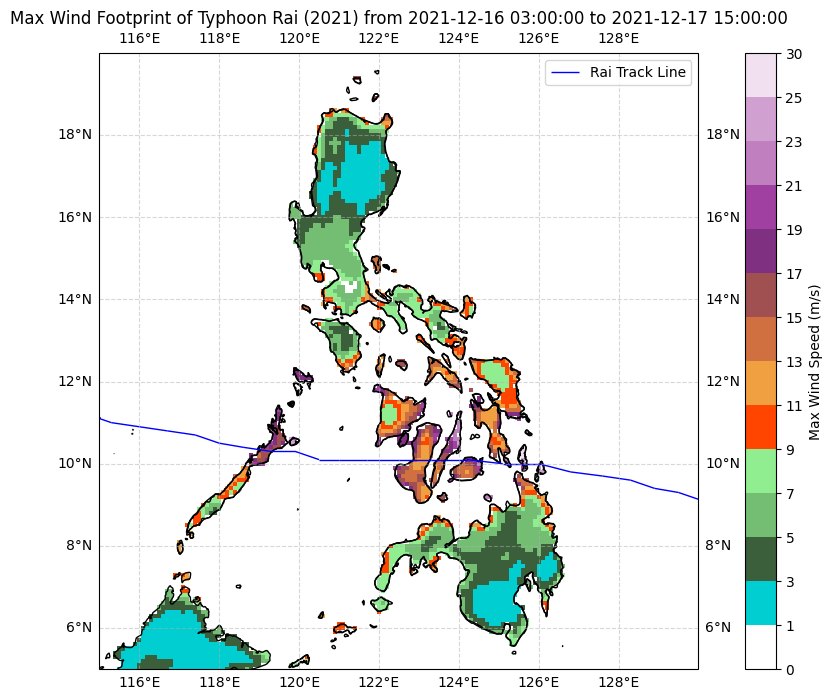

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([115, 130, 5, 20], crs=ccrs.PlateCarree())  # Philippines region
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot maximum wind speed
wind_plot = wind_speed_max.plot(ax=ax, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),
                                cbar_kwargs={'label': 'Max Wind Speed (m/s)', 'ticks': bins})
# Overlay Philippines boundary
phl_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)
# Overlay buffer
# buffer_gdf.plot(ax=ax, facecolor='none', edgecolor='red', linestyle='--', linewidth=1)
# Overlay Rai's track line
rai_lines.plot(ax=ax, color='blue', linewidth=1, label='Rai Track Line')

ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
ax.set_title(f"Max Wind Footprint of Typhoon Rai (2021) from {entry_time} to {exit_time}")
ax.legend()
plt.show()